In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_excel("/content/sample_data/Kenya Electronic Payments Data_Central Bank of Kenya.xlsx")
df.head()


,Date,Mobile Money Transactions Volume (Millions),POS Transactions Volume (Millions),RTGS Transactions Volume (Millions),EFT Transactions Volume (Millions),Debit Cards Transactions Volume (Millions),Unnamed: 6,Unnamed: 7
0,2010-01-31,20.0767,0.496450,0.056862,0.677331,7.241399,NaN,Source: https://www.centralbank.go.ke/
1,2010-02-28,20.8087,0.431833,0.065010,0.854677,6.867328,NaN,NaN
2,2010-03-31,24.0758,0.395891,0.077058,1.147958,6.647688,NaN,NaN
3,2010-04-30,22.6933,0.451366,0.069634,0.890953,6.843646,NaN,NaN
4,2010-05-31,24.6984,0.466463,0.072588,0.882688,7.240815,NaN,NaN


In [12]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 8 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Date                                         156 non-null    datetime64[ns]
 1   Mobile Money Transactions Volume (Millions)  156 non-null    float64       
 2   POS Transactions Volume (Millions)           156 non-null    float64       
 3   RTGS Transactions Volume (Millions)          156 non-null    float64       
 4   EFT Transactions Volume (Millions)           156 non-null    float64       
 5   Debit Cards Transactions Volume (Millions)   156 non-null    float64       
 6   Unnamed: 6                                   0 non-null      float64       
 7   Unnamed: 7                                   1 non-null      object        
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 9.9+ KB


,Date,Mobile Money Transactions Volume (Millions),POS Transactions Volume (Millions),RTGS Transactions Volume (Millions),EFT Transactions Volume (Millions),Debit Cards Transactions Volume (Millions),Unnamed: 6,Unnamed: 7
0,2010-01-31,20.0767,0.496450,0.056862,0.677331,7.241399,NaN,Source: https://www.centralbank.go.ke/
1,2010-02-28,20.8087,0.431833,0.065010,0.854677,6.867328,NaN,NaN
2,2010-03-31,24.0758,0.395891,0.077058,1.147958,6.647688,NaN,NaN
3,2010-04-30,22.6933,0.451366,0.069634,0.890953,6.843646,NaN,NaN
4,2010-05-31,24.6984,0.466463,0.072588,0.882688,7.240815,NaN,NaN


In [13]:
pd.ExcelFile("/content/sample_data/Kenya Electronic Payments Data_Central Bank of Kenya.xlsx").sheet_names

['Combined Data']

In [14]:
df = df.drop(columns=['Unnamed: 6', 'Unnamed: 7'])
display(df.head())


,Date,Mobile Money Transactions Volume (Millions),POS Transactions Volume (Millions),RTGS Transactions Volume (Millions),EFT Transactions Volume (Millions),Debit Cards Transactions Volume (Millions)
0,2010-01-31,20.0767,0.496450,0.056862,0.677331,7.241399
1,2010-02-28,20.8087,0.431833,0.065010,0.854677,6.867328
2,2010-03-31,24.0758,0.395891,0.077058,1.147958,6.647688
3,2010-04-30,22.6933,0.451366,0.069634,0.890953,6.843646
4,2010-05-31,24.6984,0.466463,0.072588,0.882688,7.240815


In [15]:
df.head()


,Date,Mobile Money Transactions Volume (Millions),POS Transactions Volume (Millions),RTGS Transactions Volume (Millions),EFT Transactions Volume (Millions),Debit Cards Transactions Volume (Millions)
0,2010-01-31,20.0767,0.496450,0.056862,0.677331,7.241399
1,2010-02-28,20.8087,0.431833,0.065010,0.854677,6.867328
2,2010-03-31,24.0758,0.395891,0.077058,1.147958,6.647688
3,2010-04-30,22.6933,0.451366,0.069634,0.890953,6.843646
4,2010-05-31,24.6984,0.466463,0.072588,0.882688,7.240815


In [16]:
df.isnull().sum()

,0
Date,0
Mobile Money Transactions Volume (Millions),0
POS Transactions Volume (Millions),0
RTGS Transactions Volume (Millions),0
EFT Transactions Volume (Millions),0
Debit Cards Transactions Volume (Millions),0


In [17]:
df = df.set_index('Date')
display(df.head())

,Mobile Money Transactions Volume (Millions),POS Transactions Volume (Millions),RTGS Transactions Volume (Millions),EFT Transactions Volume (Millions),Debit Cards Transactions Volume (Millions)
Date,,,,,
2010-01-31,20.0767,0.496450,0.056862,0.677331,7.241399
2010-02-28,20.8087,0.431833,0.065010,0.854677,6.867328
2010-03-31,24.0758,0.395891,0.077058,1.147958,6.647688
2010-04-30,22.6933,0.451366,0.069634,0.890953,6.843646
2010-05-31,24.6984,0.466463,0.072588,0.882688,7.240815


In [19]:
df_yearly = df.resample("YE").sum()       # yearly totals
df_yearly.index = df_yearly.index.year   # simplify index
display(df_yearly.head())

,Mobile Money Transactions Volume (Millions),POS Transactions Volume (Millions),RTGS Transactions Volume (Millions),EFT Transactions Volume (Millions),Debit Cards Transactions Volume (Millions)
Date,,,,,
2010,311.0462,5.496360,0.904717,10.928470,86.181441
2011,432.9982,6.570151,1.241533,9.537967,114.744549
2012,577.3742,11.302787,1.568125,9.261213,216.262482
2013,732.5971,15.764922,1.977887,9.926929,91.141924
2014,911.3351,11.635358,2.525340,10.676354,88.608069


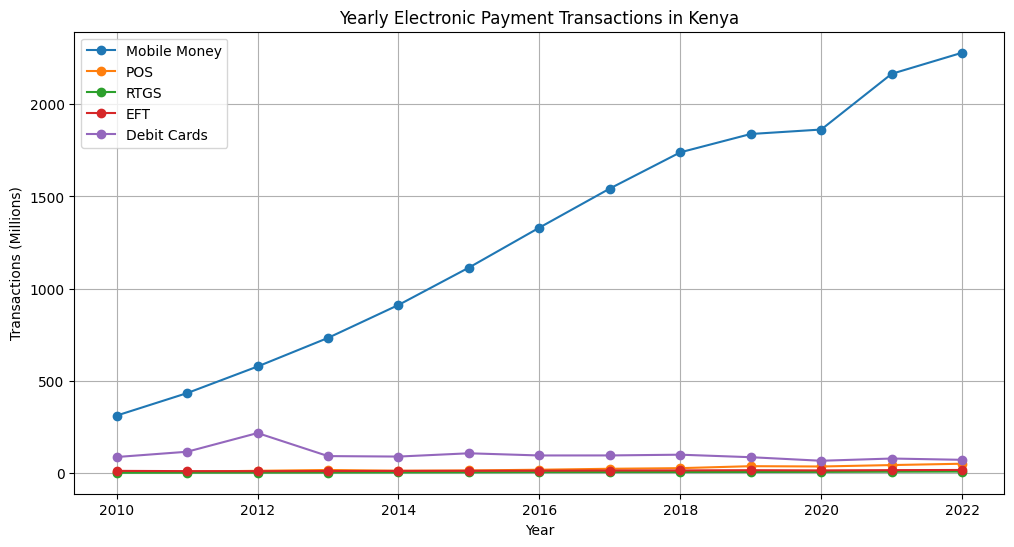

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
for col in df_yearly.columns:
    plt.plot(df_yearly.index, df_yearly[col], marker="o", label=col.split(" Transactions")[0])
plt.title("Yearly Electronic Payment Transactions in Kenya")
plt.xlabel("Year")
plt.ylabel("Transactions (Millions)")
plt.legend()
plt.grid(True)
plt.show()

,Mobile Money Transactions Volume (Millions),POS Transactions Volume (Millions),RTGS Transactions Volume (Millions),EFT Transactions Volume (Millions),Debit Cards Transactions Volume (Millions)
Date,,,,,
2018,12.73,14.99,4.49,4.23,4.22
2019,5.72,41.84,8.05,8.46,-13.78
2020,1.32,-4.67,7.62,-7.73,-22.73
2021,16.22,22.31,20.89,10.62,18.45
2022,5.29,17.10,9.85,5.96,-9.01


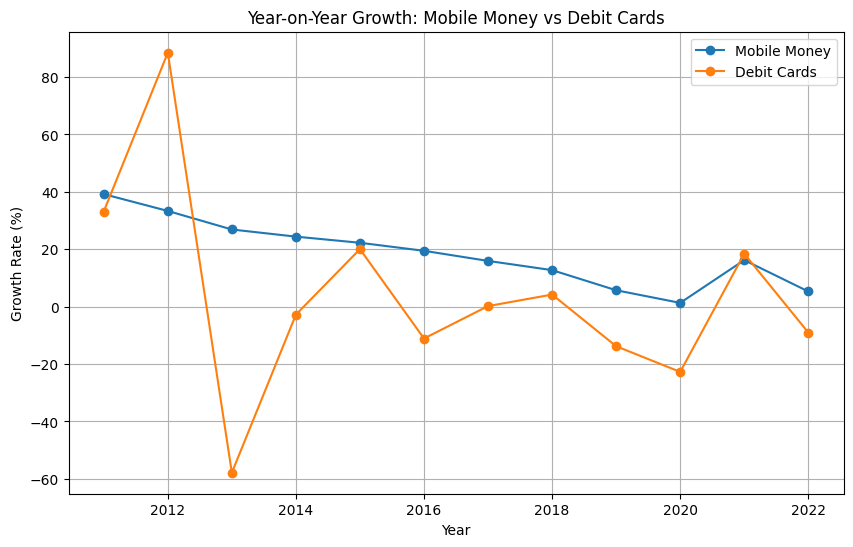

In [24]:
# GROWTH ANALYSIS
# ==============================
df_growth = df_yearly.pct_change() * 100   # percentage growth YoY
display(df_growth.round(2).tail())

plt.figure(figsize=(10,6))
plt.plot(df_growth.index, df_growth["Mobile Money Transactions Volume (Millions)"],
         marker="o", label="Mobile Money")
plt.plot(df_growth.index, df_growth["Debit Cards Transactions Volume (Millions)"],
         marker="o", label="Debit Cards")
plt.title("Year-on-Year Growth: Mobile Money vs Debit Cards")
plt.ylabel("Growth Rate (%)")
plt.xlabel("Year")
plt.legend()
plt.grid(True)
plt.show()

📈 Correlation Matrix:



,Mobile Money Transactions Volume (Millions),POS Transactions Volume (Millions),RTGS Transactions Volume (Millions),EFT Transactions Volume (Millions),Debit Cards Transactions Volume (Millions)
Mobile Money Transactions Volume (Millions),1.00,0.95,0.99,0.95,-0.50
POS Transactions Volume (Millions),0.95,1.00,0.95,0.94,-0.47
RTGS Transactions Volume (Millions),0.99,0.95,1.00,0.95,-0.51
EFT Transactions Volume (Millions),0.95,0.94,0.95,1.00,-0.60
Debit Cards Transactions Volume (Millions),-0.50,-0.47,-0.51,-0.60,1.00


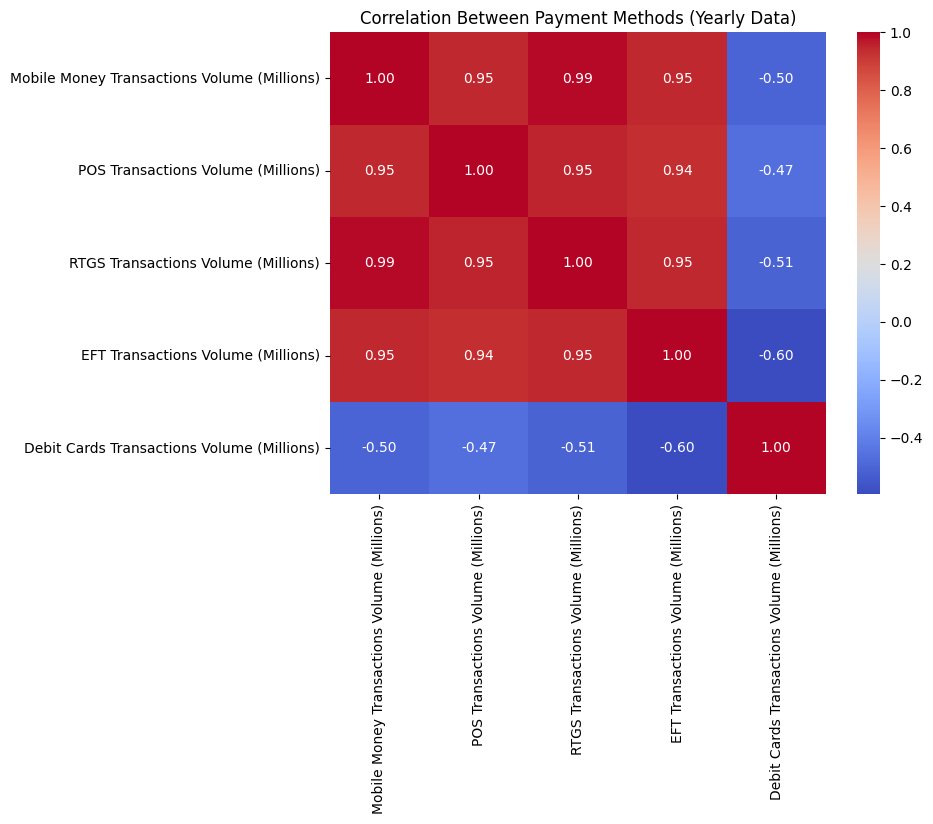

In [27]:
#  CORRELATION ANALYSIS

corr = df_yearly.corr()
print("📈 Correlation Matrix:\n")
display(corr.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Payment Methods (Yearly Data)")
plt.show()

In [26]:
import seaborn as sns